In [1]:
# Task 1: Exploratory Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

In [2]:
# Add src to path
sys.path.append(str(Path.cwd().parent))
from src.data_loader import load_data, clean_data
from src.eda_utils import *


In [3]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [9]:
# Load data
df_raw = load_data()
print(f"Data shape: {df_raw.shape}")
df_raw.head()

Data shape: (10000, 21)


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [10]:
# Clean data
df = clean_data(df_raw)
print(f"After cleaning: {df.shape}")
df.head()

After cleaning: (10000, 27)


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,TransactionMonth,TransactionYearMonth,LossRatio,Margin,HadClaim,ClaimSeverity
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,620,32238,10002,2024-05-10,2024-05,2024-05,0.000000,2346.0,0,0.0
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,Grand Vitara,52510,10001,2024-08-13,2024-08,2024-08,4.234362,-7549.0,1,9883.0
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,620,26523,20001,2025-03-17,2025-03,2025-03,0.000000,1697.0,0,0.0
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,Corolla,27036,40005,2025-03-17,2025-03,2025-03,5.119831,-9764.0,1,12134.0
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,RAV4,58348,50002,2024-11-10,2024-11,2024-11,0.000000,2582.0,0,0.0


In [11]:
# Data summary
summary = get_data_summary(df)
print(f"Missing values:\n{pd.Series(summary['missing_pct']).sort_values(ascending=False)}")


Missing values:
CustomerID              0.0
Age                     0.0
Gender                  0.0
Province                0.0
VehicleType             0.0
AnnualIncome            0.0
RiskScore               0.0
AnnualPremium           0.0
Deductible              0.0
NCD                     0.0
PastClaims              0.0
Claimed                 0.0
ClaimAmount             0.0
TotalPremium            0.0
TotalClaims             0.0
CoverType               0.0
AutoMake                0.0
VehicleModel            0.0
CustomValueEstimate     0.0
ZipCode                 0.0
TransactionDate         0.0
TransactionMonth        0.0
TransactionYearMonth    0.0
LossRatio               0.0
Margin                  0.0
HadClaim                0.0
ClaimSeverity           0.0
dtype: float64


In [12]:
# What is the overall Loss Ratio?
total_premium = df['TotalPremium'].sum()
total_claims = df['TotalClaims'].sum()
overall_loss_ratio = total_claims / total_premium
print(f"Overall Loss Ratio: {overall_loss_ratio:.3f}")
print(f"Total Premium: {total_premium:,.0f}")
print(f"Total Claims: {total_claims:,.0f}")

Overall Loss Ratio: 0.528
Total Premium: 24,881,279
Total Claims: 13,141,885


In [13]:
# By Province
province_loss = df.groupby('Province').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
})
province_loss['LossRatio'] = province_loss['TotalClaims'] / province_loss['TotalPremium']
print("\nLoss Ratio by Province:")
print(province_loss['LossRatio'].sort_values(ascending=False))



Loss Ratio by Province:
Province
Somali         0.611927
Oromia         0.537272
Tigray         0.526016
Addis Ababa    0.522400
Amhara         0.477600
Name: LossRatio, dtype: float64


In [14]:
# By Vehicle Type
vehicle_loss = df.groupby('VehicleType').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
})
vehicle_loss['LossRatio'] = vehicle_loss['TotalClaims'] / vehicle_loss['TotalPremium']
print("\nLoss Ratio by Vehicle Type:")
print(vehicle_loss['LossRatio'].sort_values(ascending=False))



Loss Ratio by Vehicle Type:
VehicleType
Luxury       0.842422
SUV          0.563729
Hatchback    0.420163
Sedan        0.404001
Name: LossRatio, dtype: float64


In [15]:
# By Gender
gender_loss = df.groupby('Gender').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
})
gender_loss['LossRatio'] = gender_loss['TotalClaims'] / gender_loss['TotalPremium']
print("\nLoss Ratio by Gender:")
print(gender_loss['LossRatio'])



Loss Ratio by Gender:
Gender
Female    0.528728
Male      0.527608
Name: LossRatio, dtype: float64


C:\Users\hp\AppData\Local\Temp\ipykernel_7788\3515110936.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df['TotalPremium'], df['TotalClaims']], labels=['Premium', 'Claims'])


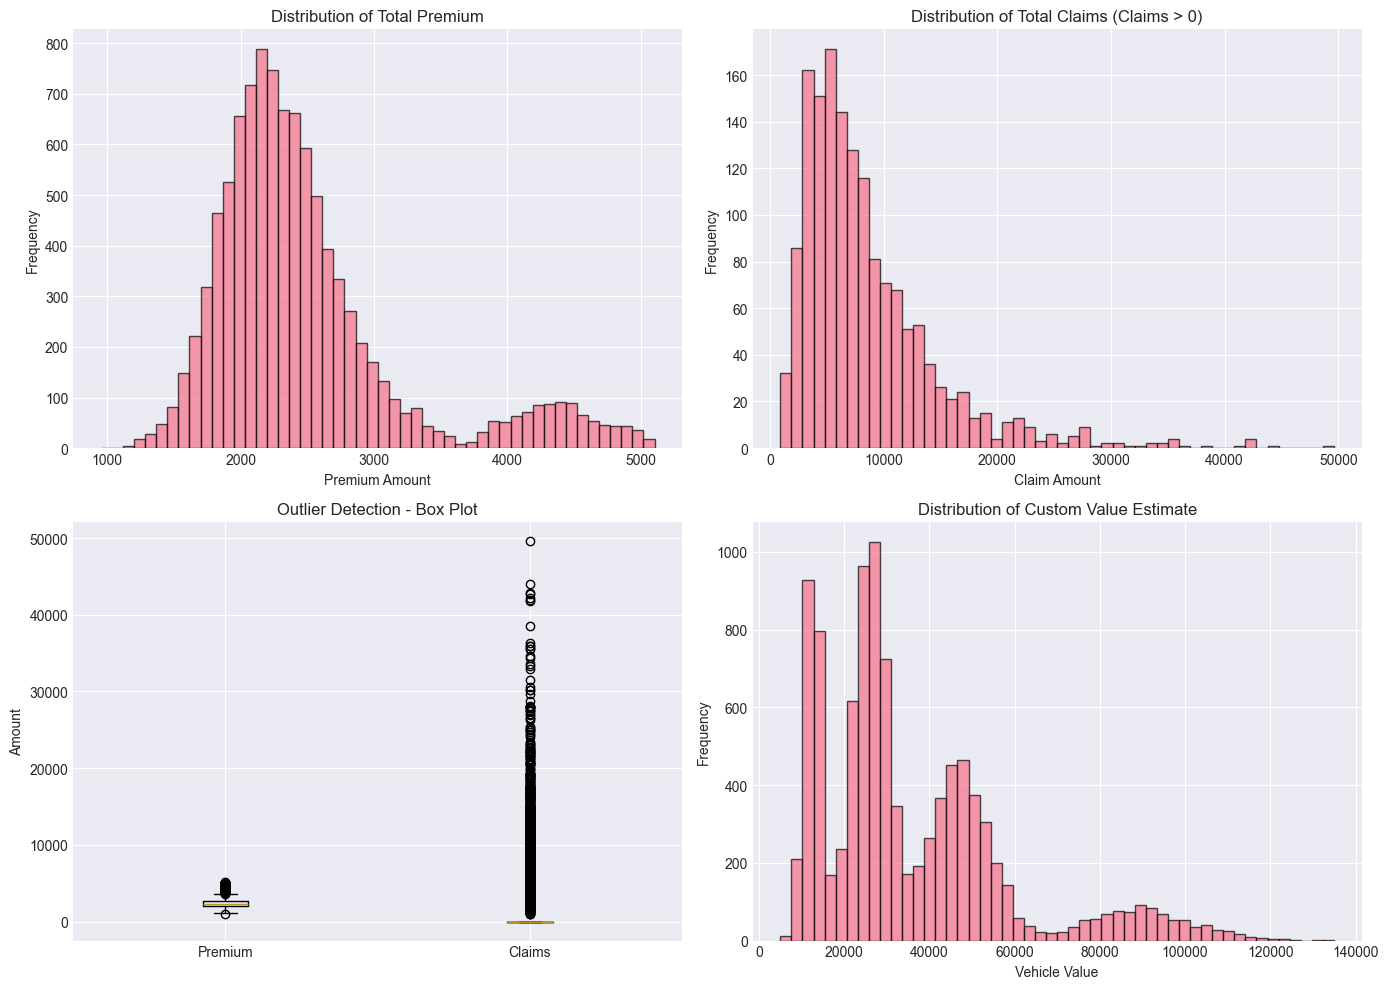

In [16]:
# Distributions of key financial variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TotalPremium distribution
axes[0, 0].hist(df['TotalPremium'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Total Premium')
axes[0, 0].set_xlabel('Premium Amount')
axes[0, 0].set_ylabel('Frequency')

# TotalClaims distribution (log scale due to skew)
axes[0, 1].hist(df[df['TotalClaims'] > 0]['TotalClaims'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Total Claims (Claims > 0)')
axes[0, 1].set_xlabel('Claim Amount')
axes[0, 1].set_ylabel('Frequency')

# Box plot for outliers
axes[1, 0].boxplot([df['TotalPremium'], df['TotalClaims']], labels=['Premium', 'Claims'])
axes[1, 0].set_title('Outlier Detection - Box Plot')
axes[1, 0].set_ylabel('Amount')

# CustomValueEstimate
axes[1, 1].hist(df['CustomValueEstimate'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of Custom Value Estimate')
axes[1, 1].set_xlabel('Vehicle Value')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [17]:
# Outlier statistics
premium_q3 = df['TotalPremium'].quantile(0.75)
premium_iqr = premium_q3 - df['TotalPremium'].quantile(0.25)
premium_outliers = df[df['TotalPremium'] > premium_q3 + 1.5 * premium_iqr]
print(f"Premium outliers: {len(premium_outliers)} ({len(premium_outliers)/len(df)*100:.1f}%)")

claims_df = df[df['TotalClaims'] > 0]
claims_q3 = claims_df['TotalClaims'].quantile(0.75)
claims_iqr = claims_q3 - claims_df['TotalClaims'].quantile(0.25)
claims_outliers = claims_df[claims_df['TotalClaims'] > claims_q3 + 1.5 * claims_iqr]
print(f"Claims outliers (among claims): {len(claims_outliers)} ({len(claims_outliers)/len(claims_df)*100:.1f}%)")

Premium outliers: 949 (9.5%)
Claims outliers (among claims): 82 (5.3%)


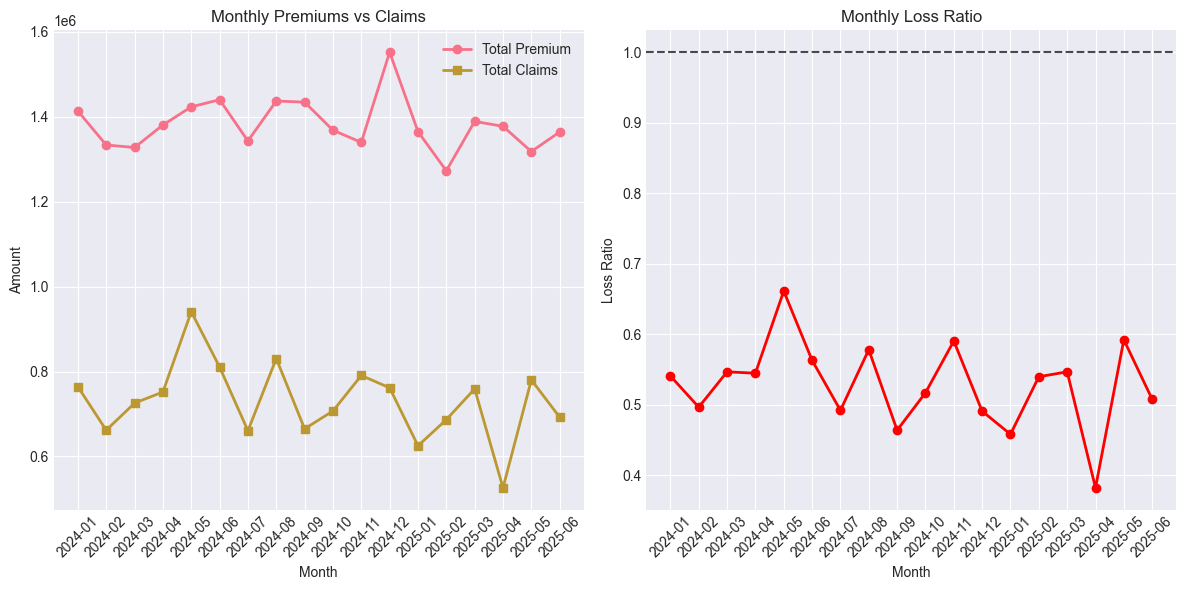

Monthly Trends:
                      Claim_Frequency  Avg_Claim_Severity
TransactionYearMonth                                     
2024-01                      0.139785         9799.025641
2024-02                      0.143126         8709.815789
2024-03                      0.150558         8959.037037
2024-04                      0.160940         8448.101124
2024-05                      0.172174         9505.787879
2024-06                      0.162912         8624.531915
2024-07                      0.143657         8579.766234
2024-08                      0.154237         9127.901099
2024-09                      0.139085         8419.075949
2024-10                      0.163043         7857.177778


In [18]:
# Temporal trends
fig = plot_monthly_trends(df)
plt.show()

monthly_stats = df.groupby('TransactionYearMonth').agg({
    'HadClaim': 'mean',
    'TotalClaims': lambda x: x[x > 0].mean() if (x > 0).any() else 0
}).rename(columns={'HadClaim': 'Claim_Frequency', 'TotalClaims': 'Avg_Claim_Severity'})

print("Monthly Trends:")
print(monthly_stats.head(10))


Top 10 Makes by Average Claim Amount:
               Avg_Claim  Count  Total_Claims
AutoMake                                     
Mercedes-Benz   13488.57     89     1200483.0
BMW             12954.77     88     1140020.0
Toyota           8545.05    527     4503241.0
Suzuki           8120.42    236     1916420.0
Hyundai          7441.92    431     3207466.0
Lifan            7160.09    164     1174255.0

Bottom 10 Makes by Average Claim Amount:
               Avg_Claim  Count  Total_Claims
AutoMake                                     
Mercedes-Benz   13488.57     89     1200483.0
BMW             12954.77     88     1140020.0
Toyota           8545.05    527     4503241.0
Suzuki           8120.42    236     1916420.0
Hyundai          7441.92    431     3207466.0
Lifan            7160.09    164     1174255.0


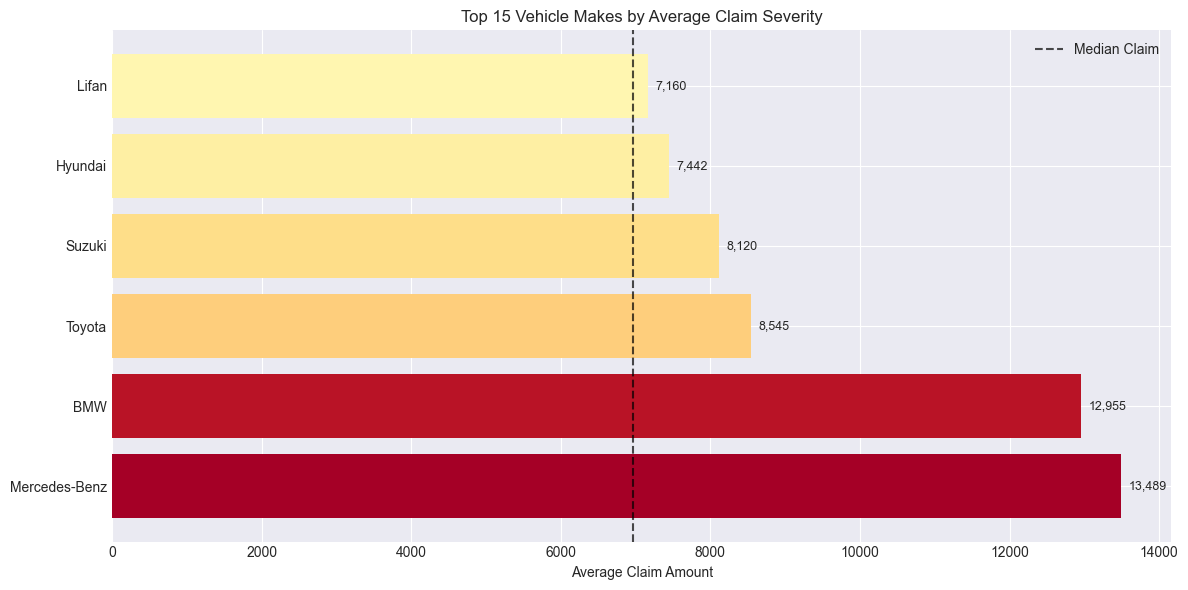

In [19]:
# Vehicle makes with highest/lowest claim amounts
claim_by_make = df[df['TotalClaims'] > 0].groupby('AutoMake').agg({
    'TotalClaims': ['mean', 'count', 'sum']
}).round(2)
claim_by_make.columns = ['Avg_Claim', 'Count', 'Total_Claims']
claim_by_make = claim_by_make.sort_values('Avg_Claim', ascending=False)

print("Top 10 Makes by Average Claim Amount:")
print(claim_by_make.head(10))

print("\nBottom 10 Makes by Average Claim Amount:")
print(claim_by_make.tail(10))

fig = plot_claim_distribution_by_make(df)
plt.show()

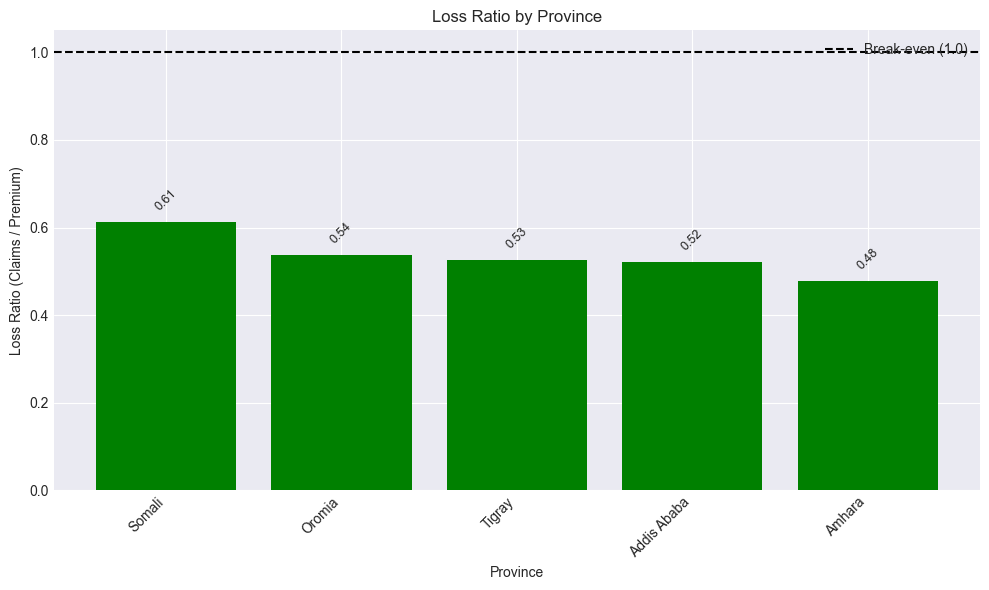

Average Premium by Province:
Province
Somali         2521.101351
Addis Ababa    2497.161200
Oromia         2481.464841
Tigray         2475.985075
Amhara         2465.515758
Name: TotalPremium, dtype: float64

Claim Frequency by Province:
Province
Somali         0.174831
Addis Ababa    0.156714
Oromia         0.154129
Tigray         0.140547
Amhara         0.139570
Name: HadClaim, dtype: float64


In [20]:
# Geographic trends
fig = plot_loss_ratio_by_category(df, 'Province')
plt.show()

# Premium by province
premium_by_province = df.groupby('Province')['TotalPremium'].mean().sort_values(ascending=False)
print("Average Premium by Province:")
print(premium_by_province)

# Claim frequency by province
claim_freq_by_province = df.groupby('Province')['HadClaim'].mean().sort_values(ascending=False)
print("\nClaim Frequency by Province:")
print(claim_freq_by_province)

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


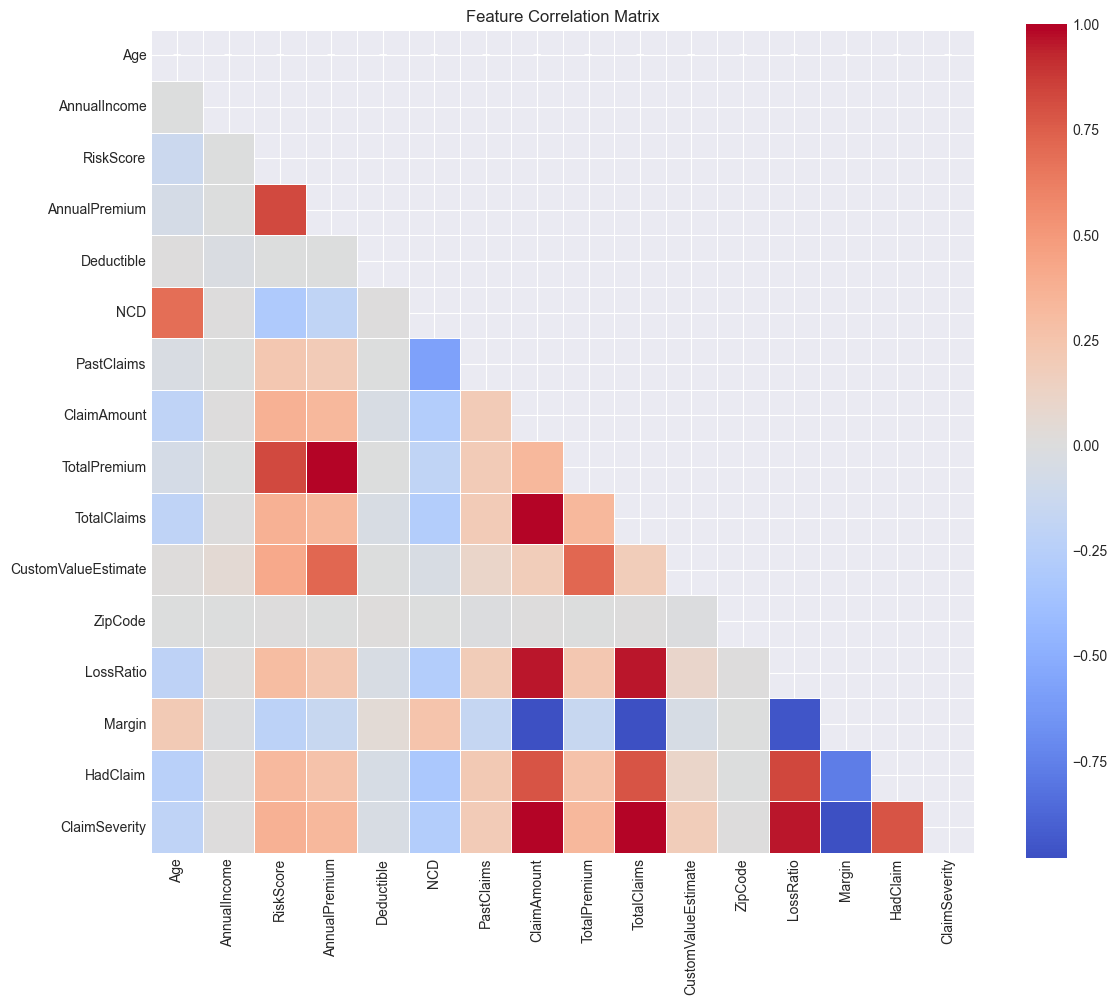

Correlations with TotalClaims:
TotalClaims            1.000000
RiskScore              0.365128
TotalPremium           0.331404
AnnualPremium          0.331404
CustomValueEstimate    0.182116
AnnualIncome           0.008045
Age                   -0.205557
NCD                   -0.275695
Name: TotalClaims, dtype: float64


In [21]:
# Correlation analysis
fig = plot_correlation_heatmap(df)
plt.show()

# Key correlations with TotalClaims
correlations = df[['TotalPremium', 'TotalClaims', 'RiskScore', 'AnnualIncome', 
                   'Age', 'CustomValueEstimate', 'NCD', 'AnnualPremium']].corr()['TotalClaims'].sort_values(ascending=False)
print("Correlations with TotalClaims:")
print(correlations)


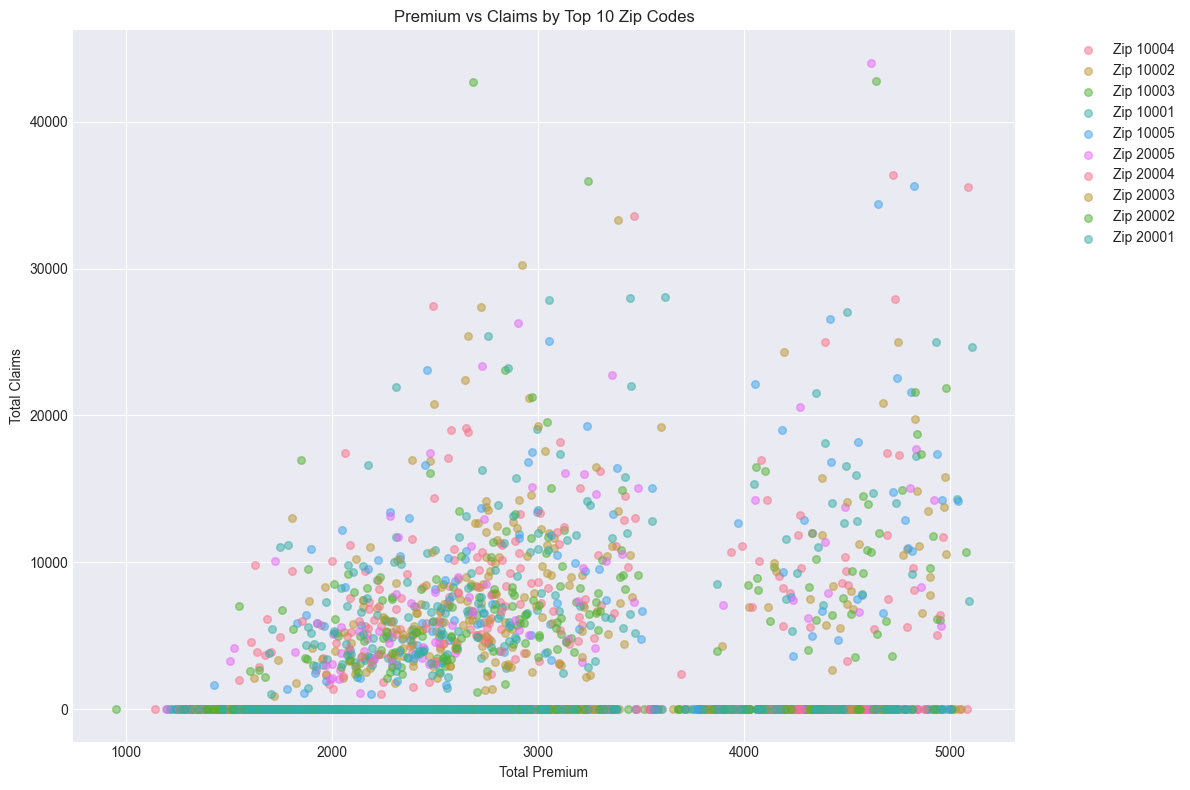

In [22]:
# Bivariate analysis: Premium vs Claims by ZipCode
# Get top 10 zip codes by volume
top_zips = df['ZipCode'].value_counts().head(10).index

fig, ax = plt.subplots(figsize=(12, 8))
for zipcode in top_zips:
    subset = df[df['ZipCode'] == zipcode]
    ax.scatter(subset['TotalPremium'], subset['TotalClaims'], alpha=0.5, label=f'Zip {zipcode}', s=30)

ax.set_xlabel('Total Premium')
ax.set_ylabel('Total Claims')
ax.set_title('Premium vs Claims by Top 10 Zip Codes')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [23]:
# Save insights summary
insights_summary = {
    'overall_loss_ratio': overall_loss_ratio,
    'total_premium': total_premium,
    'total_claims': total_claims,
    'claim_rate': df['HadClaim'].mean(),
    'avg_claim_severity': df[df['TotalClaims'] > 0]['TotalClaims'].mean(),
    'median_claim_severity': df[df['TotalClaims'] > 0]['TotalClaims'].median(),
    'high_risk_province': province_loss['LossRatio'].idxmax(),
    'low_risk_province': province_loss['LossRatio'].idxmin(),
    'high_risk_vehicle': vehicle_loss['LossRatio'].idxmax(),
    'low_risk_vehicle': vehicle_loss['LossRatio'].idxmin(),
}

print("\n=== KEY INSIGHTS SUMMARY ===")
for key, value in insights_summary.items():
    print(f"{key}: {value}")


=== KEY INSIGHTS SUMMARY ===
overall_loss_ratio: 0.5281836596904845
total_premium: 24881279
total_claims: 13141885.0
claim_rate: 0.1535
avg_claim_severity: 8561.488599348535
median_claim_severity: 6968.0
high_risk_province: Somali
low_risk_province: Amhara
high_risk_vehicle: Luxury
low_risk_vehicle: Sedan
